# Modelo de regresión logística

# Programa o Script desarrollado por : Rolando Ortiz Herbas

In [8]:
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from decimal import Decimal, getcontext

# Lectura del Dataset de entrenamiento : Clientes_Dos_Mil_TransEntrenamiento.csv

In [9]:
getcontext().prec = 30
ruta = "C:/Users/Roland/Documents/UNAD_MEXICO_Matematicas_2022/Semestre_2024_1/ZZZ_Word_y_PT/DatosClientes/Clientes_Dos_Mil_TransEntrenamiento.csv"

df = pd.read_csv(ruta , header=0)

In [10]:
df.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV,Y
0,50.0,1.169816,-0.192756,0.0,0.0,-0.166641,-0.023268,0.705376,-0.166641,-0.509295,...,1.0,0.0,0.0,0.0,0.521302,-2.017655,-0.450162,0.139169,1.153685,1
1,52.0,-0.208486,-0.543173,0.0,0.0,0.534826,1.227955,0.698809,0.534826,-0.562703,...,1.0,0.0,0.0,0.0,0.656970,-1.041528,-0.450162,0.139169,-0.266833,1
2,25.0,-1.731874,-1.536804,7.0,1.0,1.851247,1.892303,0.698950,1.851247,-0.870487,...,0.0,0.0,2.0,2.0,-0.258793,0.910727,-0.450162,0.139169,-1.911644,1
3,85.0,-0.135944,0.886252,7.0,1.0,0.534826,0.621728,0.705376,0.534826,0.180678,...,0.0,0.0,2.0,2.0,-0.224876,-0.065401,-0.450162,0.139169,-0.117305,1
4,62.0,-2.747465,-1.748252,1.0,1.0,1.830804,1.253629,-0.685136,1.830804,0.371814,...,0.0,0.0,1.0,2.0,-1.411976,-2.993783,-0.450162,0.139169,-2.285465,0


In [11]:
df = df.astype({col: 'float64' for col in df.select_dtypes(include='int64').columns})

# Verificar los tipos de datos
print(df.dtypes)

Ocupacion             float64
NoPago                float64
TotalMonto            float64
EstadoContrato        float64
Producto              float64
FechaInicioC          float64
FechaAdjudicación     float64
FechaUltimoPago       float64
FechaProyectadaFin    float64
MontoVencido          float64
Mensualidad           float64
Ingresos              float64
Legal                 float64
EdadActual            float64
AZULEstatus           float64
AdjudicaReal          float64
PagosPuntuales        float64
CostoAdmin            float64
Genero                float64
PersonaTipo           float64
dtEstadoContrato      float64
GrupoOrigenVenta      float64
SemanasAdjud          float64
Pagos9                float64
Domicilia_Pago        float64
Email                 float64
timetotV              float64
Y                     float64
dtype: object


# Inicializa coeficientes y lee las variables

In [12]:

X = np.array(df.iloc[:, :-1])

X1 = df.iloc[:, :-1]
#X = np.array(X1)
Y = np.array(df["Y"])


In [13]:
X1.head()

,Ocupacion,NoPago,TotalMonto,EstadoContrato,Producto,FechaInicioC,FechaAdjudicación,FechaUltimoPago,FechaProyectadaFin,MontoVencido,...,CostoAdmin,Genero,PersonaTipo,dtEstadoContrato,GrupoOrigenVenta,SemanasAdjud,Pagos9,Domicilia_Pago,Email,timetotV
0,50.0,1.169816,-0.192756,0.0,0.0,-0.166641,-0.023268,0.705376,-0.166641,-0.509295,...,0.918037,1.0,0.0,0.0,0.0,0.521302,-2.017655,-0.450162,0.139169,1.153685
1,52.0,-0.208486,-0.543173,0.0,0.0,0.534826,1.227955,0.698809,0.534826,-0.562703,...,-0.365007,1.0,0.0,0.0,0.0,0.656970,-1.041528,-0.450162,0.139169,-0.266833
2,25.0,-1.731874,-1.536804,7.0,1.0,1.851247,1.892303,0.698950,1.851247,-0.870487,...,-1.708139,0.0,0.0,2.0,2.0,-0.258793,0.910727,-0.450162,0.139169,-1.911644
3,85.0,-0.135944,0.886252,7.0,1.0,0.534826,0.621728,0.705376,0.534826,0.180678,...,-0.309597,0.0,0.0,2.0,2.0,-0.224876,-0.065401,-0.450162,0.139169,-0.117305
4,62.0,-2.747465,-1.748252,1.0,1.0,1.830804,1.253629,-0.685136,1.830804,0.371814,...,-2.517351,0.0,0.0,1.0,2.0,-1.411976,-2.993783,-0.450162,0.139169,-2.285465


# Lectura del dataset de prueba 

In [14]:
ruta_prueba = "C:/Users/Roland/Documents/UNAD_MEXICO_Matematicas_2022/Semestre_2024_1/ZZZ_Word_y_PT/DatosClientes/Clientes_Dos_Mil_TransPrueba.csv"
df_prueba = pd.read_csv(ruta_prueba , header=0)

# generar la Matriz de Covarianzas

Matriz de Covarianzas:
                      Ocupacion     NoPago  TotalMonto  EstadoContrato  \
Ocupacion           1099.442595   0.033580    0.260653       -2.062189   
NoPago                 0.033580   1.014209    0.653042       -0.493801   
TotalMonto             0.260653   0.653042    0.988814        0.081383   
EstadoContrato        -2.062189  -0.493801    0.081383        7.095785   
Producto              -0.290041  -0.128387   -0.064580       -0.029644   
FechaInicioC           0.170390  -0.486111   -0.245132        0.340153   
FechaAdjudicación      0.835876  -0.371827   -0.210550        0.113731   
FechaUltimoPago       -0.073246   0.347401    0.290732       -0.063937   
FechaProyectadaFin     0.170390  -0.486111   -0.245132        0.340153   
MontoVencido           0.833772  -0.049712    0.047005        0.066639   
Mensualidad            0.244624   0.633753    0.984125        0.077294   
Ingresos              -0.245935   0.584636    0.881221        0.051602   
Legal          

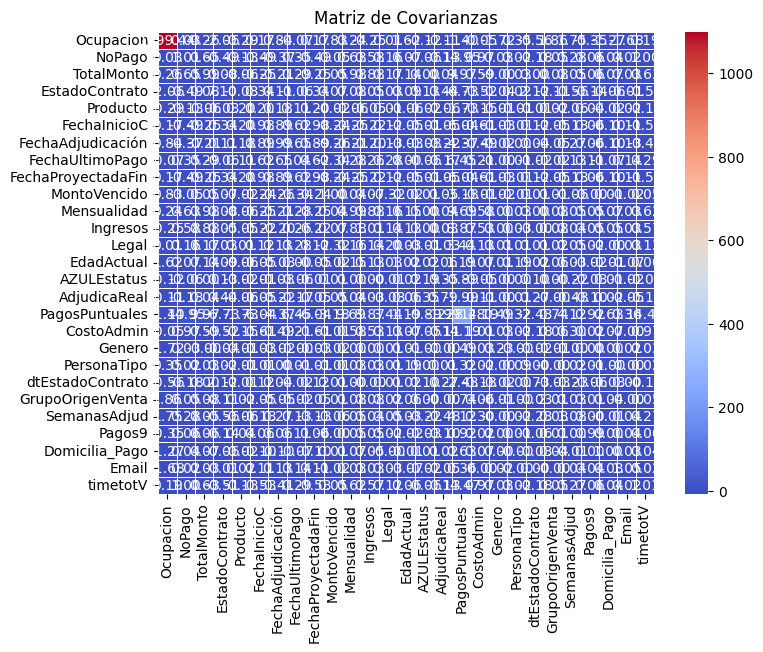

In [24]:
# Mostrar la matriz de covarianzas
cov_matrix = X1.cov()
print("Matriz de Covarianzas:")
print(cov_matrix)

# Generar la gráfica de la matriz de covarianzas usando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Covarianzas')
plt.show()

In [25]:
# Calcular los eigenvalores y eigenvectores de la matriz de covarianzas
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Mostrar los eigenvalores y eigenvectores
print("Eigenvalores:")
print(eigenvalues)

Eigenvalores:
[1.09946590e+03 2.33292075e+02 7.67541126e+00 3.67562943e+00
 2.03514739e+00 1.75857735e+00 1.37667147e+00 1.12560887e+00
 1.00586380e+00 9.65987342e-01 9.40568769e-01 7.34050774e-01
 4.98917476e-01 2.19827079e-01 1.52575686e-01 1.36055099e-01
 8.62944814e-02 6.21848832e-02 5.02236265e-02 3.84818213e-02
 3.42860598e-02 2.19239031e-02 1.87635151e-02 1.48307275e-02
 2.61471526e-03 1.49122411e-03 1.18387884e-16]


In [26]:
print("\nEigenvectores:")
print(eigenvectors)

# Ordenar los eigenvalores de mayor a menor
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]


Eigenvectores:
[[-9.99989142e-01  1.49438898e-03  2.04264165e-03  1.97920569e-04
   1.73970566e-03 -4.19482396e-04 -1.05367178e-03 -2.52492221e-03
  -8.67459848e-04 -3.14051406e-04 -9.23569772e-05 -5.71299607e-04
   9.26828482e-04  1.50104081e-03 -4.03848246e-04  1.28041718e-04
  -2.27007747e-04  2.99071860e-05 -2.00409985e-05  1.22795763e-04
  -4.39874874e-05  3.97707974e-05 -4.13071601e-05  1.80736712e-04
  -6.46073812e-06 -8.74175631e-06  1.31115817e-19]
 [-1.01101501e-05  6.48497149e-02 -6.99798483e-03  5.62757710e-02
   5.69610703e-03  2.07232515e-04  5.54473492e-02 -2.61895103e-02
   3.80157732e-02  1.70035200e-02 -3.29542383e-03  1.20416420e-01
  -8.03542250e-03  5.54864140e-03 -1.39687504e-02 -3.15918119e-03
  -4.93020663e-03  2.17657587e-02 -5.36307339e-03  1.53983130e-01
  -2.68982331e-02 -2.08820439e-03 -4.89661067e-02 -2.91552265e-01
   3.48151186e-03 -9.27287451e-01 -1.52661900e-15]
 [-2.22848263e-04  4.34128434e-02  6.76960328e-02  3.41888207e-02
  -1.67193191e-01 -4.377

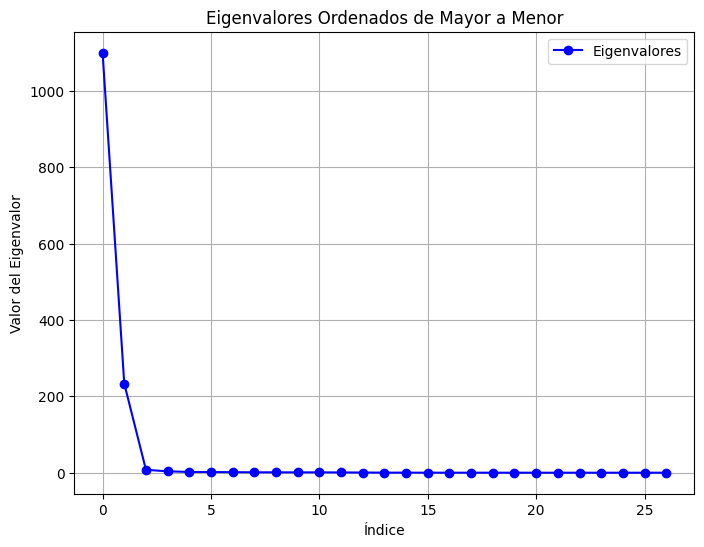

In [18]:
# Graficar los eigenvalores ordenados de mayor a menor
plt.figure(figsize=(8, 6))
plt.plot(sorted_eigenvalues, marker='o', linestyle='-', color='b', label='Eigenvalores')
plt.title('Eigenvalores Ordenados de Mayor a Menor')
plt.xlabel('Índice')
plt.ylabel('Valor del Eigenvalor')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Mostrar los eigenvectores ordenados
print("\nEigenvectores ordenados correspondientes a los eigenvalores:")
print(sorted_eigenvectors)

In [20]:
# Calcular la varianza de cada columna

variances = X1.var()

# Ordenar las varianzas de mayor a menor
sorted_variances = variances.sort_values(ascending=False)

In [21]:
# Mostrar las varianzas ordenadas
print("Varianzas ordenadas:")
print(sorted_variances)

Varianzas ordenadas:
Ocupacion             1099.442595
PagosPuntuales         228.275919
EstadoContrato           7.095785
GrupoOrigenVenta         2.008333
SemanasAdjud             1.080638
Email                    1.052216
FechaUltimoPago          1.040853
EdadActual               1.016100
NoPago                   1.014209
timetotV                 1.010692
CostoAdmin               1.010552
Ingresos                 1.005010
Domicilia_Pago           1.001809
MontoVencido             1.000366
Pagos9                   0.992165
TotalMonto               0.988814
FechaAdjudicación        0.987782
Mensualidad              0.986122
FechaInicioC             0.982692
FechaProyectadaFin       0.982692
AdjudicaReal             0.786585
dtEstadoContrato         0.732131
Genero                   0.225531
Producto                 0.196646
Legal                    0.195190
AZULEstatus              0.189479
PersonaTipo              0.089054
dtype: float64


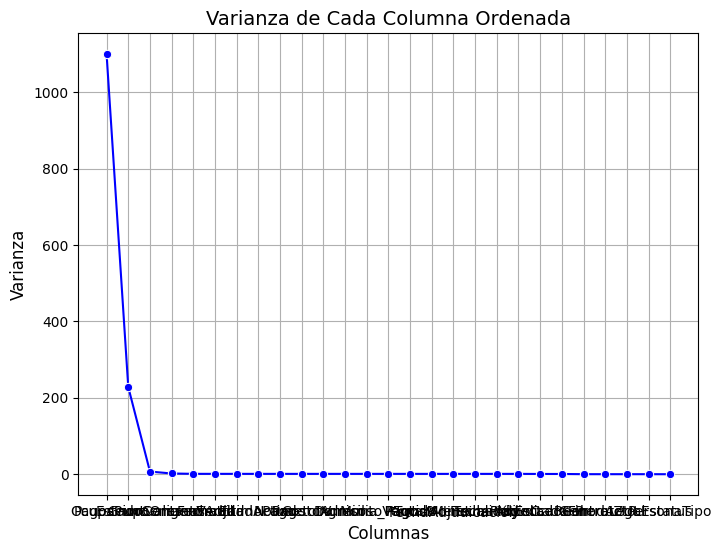

In [23]:
# Graficar las varianzas ordenadas
plt.figure(figsize=(8, 6))
sns.lineplot(x=sorted_variances.index, y=sorted_variances.values, marker='o', color='b')

# Personalización de la gráfica
plt.title('Varianza de Cada Columna Ordenada', fontsize=14)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Varianza', fontsize=12)
plt.grid(True)
plt.show()